# VJeaNETte Reproducibility Notebook

## 1. Project overview 

### VJeaNETte inference reproducibility

This notebook demonstrates:
- loading trained UNet1D model
- FASTQ preprocessing
- V/J/CDR3 inference
- running the full pipeline

The goal is to reproduce inference results from the paper/project.

## 2. Imports and environment

In [1]:
import argparse
import csv
import logging
import time

import mmap
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import IterableDataset

In [2]:
import sys
import torch

print(sys.version)
print(torch.__version__)

3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]
2.5.1+cu121


## 3. Constants and configuration

### Global constants and thresholds

In [3]:
MAX_LEN = 512

RC_TABLE = torch.tensor([3,2,1,0,4,5], dtype=torch.uint8)

DEFAULT_THRESHOLDS = {
    "v_exist": 0.02,
    "j_exist": 0.02,
    "cdr_exist": 0.02,
    "mask": 0.04
}

## 4. FASTQ preprocessing

### FASTQ streaming dataset

The dataset implementation uses:

- memory mapped FASTQ reading (`mmap`)
- iterable dataset design
- multithreaded workers
- byte-level nucleotide encoding

This allows efficient processing of very large sequencing datasets.

In [4]:
CHAR_MAP = np.full(256, 4, dtype=np.uint8)

CHAR_MAP[ord("A")] = 0
CHAR_MAP[ord("C")] = 1
CHAR_MAP[ord("G")] = 2
CHAR_MAP[ord("T")] = 3
CHAR_MAP[ord("N")] = 4
CHAR_MAP[ord("P")] = 5

In [5]:
def seq_to_indices_bytes(seq_bytes):
    arr = np.frombuffer(seq_bytes, dtype=np.uint8)
    return CHAR_MAP[arr]
def filling_bytes(seq_bytes):
    seq = seq_bytes[:MAX_LEN]
    if len(seq) < MAX_LEN:
        seq += b"P" * (MAX_LEN - len(seq))
    return seq


In [6]:

class FastqDataset(IterableDataset): 

    def __init__(self, path, batch_size, num_workers):
        self.path = path
        self.batch_size = batch_size
        self.num_workers = num_workers

    def parse_fastq(self, worker_id):

        f = open(self.path, "rb")
        mm = mmap.mmap(f.fileno(), 0, access=mmap.ACCESS_READ)

        size = mm.size()
        chunk = size // self.num_workers

        start = worker_id * chunk
        end = size if worker_id == self.num_workers-1 else (worker_id+1)*chunk

        mm.seek(start)

        if start != 0:
            mm.readline()
            while True:
                pos = mm.tell()
                line = mm.readline()
                if not line:
                    break
                if line.startswith(b'@'):
                    mm.seek(pos)
                    break

        batch = []
        ids = []

        while mm.tell() < end:

            header = mm.readline()
            if not header:
                break

            seq = mm.readline().rstrip()
            mm.readline()
            mm.readline()

            read_id = header[1:].split()[0].decode()

            seq = filling_bytes(seq)

            batch.append(seq_to_indices_bytes(seq))
            ids.append(read_id)

            if len(batch) == self.batch_size:
                yield torch.from_numpy(np.stack(batch)).long(), ids
                batch, ids = [], []

        if batch:
            yield torch.from_numpy(np.stack(batch)).long(), ids

        mm.close()
        f.close()

    def __iter__(self):

        worker_info = torch.utils.data.get_worker_info()

        if worker_info is None:
            worker_id = 0
        else:
            worker_id = worker_info.id

        yield from self.parse_fastq(worker_id)

## 5. CUDA setup

In [7]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)

DEVICE: cuda


## 6. UNet architecture

### Model architecture

The model is based on a 1D U-Net encoder-decoder architecture
with separate heads for:
- V segment
- J segment
- CDR3 region

In [8]:
class UNet1D_Embed(nn.Module):
    def __init__(self, embed_dim=32, out_channels=1, features=[8,16,64,64]):
        super().__init__()
        PADDING_IDX = 5
        self.embed = nn.Embedding(num_embeddings=6, embedding_dim=embed_dim, padding_idx=PADDING_IDX)
        
        in_channels = embed_dim
        
        # Encoder
        self.enc1 = self._encoder_block(in_channels, features[0])
        self.enc2 = self._encoder_block(features[0], features[1])
        self.enc3 = self._encoder_block(features[1], features[2])
        self.enc4 = self._encoder_block(features[2], features[3])
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv1d(features[3], features[3]*2, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(features[3]*2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv1d(features[3]*2, features[3]*2, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(features[3]*2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )
        
        # Decoder
        self.up4 = nn.ConvTranspose1d(features[3]*2, features[3], kernel_size=2, stride=2)
        self.dec4 = self._decoder_block(features[3]+features[2], features[2])
        
        self.up3 = nn.ConvTranspose1d(features[2], features[2], kernel_size=2, stride=2)
        self.dec3 = self._decoder_block(features[2]+features[1], features[1])
        
        self.up2 = nn.ConvTranspose1d(features[1], features[1], kernel_size=2, stride=2)
        self.dec2 = self._decoder_block(features[1]+features[0], features[0])
        
        self.up1 = nn.ConvTranspose1d(features[0], features[0], kernel_size=2, stride=2)
        
        self.final_conv = nn.Sequential(
            nn.Conv1d(features[0], features[0], kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(features[0]),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv1d(features[0], features[0], kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(features[0]),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )
        
        self.v_head = nn.Sequential(
            nn.Conv1d(features[0], features[0]//2, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(features[0]//2, out_channels, kernel_size=1)
        )
        self.j_head = nn.Sequential(
            nn.Conv1d(features[0], features[0]//2, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(features[0]//2, out_channels, kernel_size=1)
        )
        self.cdr_head = nn.Sequential(
            nn.Conv1d(features[0], features[0]//2, kernel_size = 1),
            nn.ReLU(inplace = True),
            nn.Conv1d(features[0]//2, out_channels, kernel_size = 1)
        )
        
    
    def _encoder_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Conv1d(out_channels, out_channels, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.MaxPool1d(2)
        )
    
    def _decoder_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Conv1d(out_channels, out_channels, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35)
        )
    
    def forward(self, x):
        """
        x: [B, L] LongTensor индексы 0..5
        """
        x = self.embed(x).transpose(1, 2)  # [B, embed_dim, L]
        
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        
        b = self.bottleneck(e4)
        
        d4 = self.up4(b)
        d4 = torch.cat((d4, e3), dim=1)
        d4 = self.dec4(d4)
        
        d3 = self.up3(d4)
        d3 = torch.cat((d3, e2), dim=1)
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        d2 = torch.cat((d2, e1), dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        d1 = self.final_conv(d1)
        
        v_out = self.v_head(d1)
        j_out = self.j_head(d1)
        cdr_out = self.cdr_head(d1)
        
        return v_out.squeeze(1), j_out.squeeze(1), cdr_out.squeeze(1)

## 7. Utility functions

In [9]:
def reverse_complement(x):
    """Reverse complement"""
    return RC_TABLE.to(x.device)[x].flip(1)

def get_intervals_fast(probs, thr):
    """Fast intervals defining"""
    mask = probs > thr
    
    any_mask = mask.any(1)
    mask_int = mask.to(torch.int8)
    starts = torch.argmax(mask_int, dim=1)
    ends = mask.size(1) - torch.argmax(mask_int.flip(1), dim=1) - 1
    
    starts[~any_mask] = -1
    ends[~any_mask] = -1
    
    return starts, ends

def calculate_scores(has_v, has_j, max_v, max_j):
    """Score calculation"""
    return 2*has_v.float() + 2*has_j.float() + max_v + max_j

def select_best_strand(vf, vr, jf, jr, has_vf, has_vr, has_jf, has_jr):
    """Select best strand (forward/reverse)"""
    max_vf = vf.max(1).values
    max_vr = vr.max(1).values
    max_jf = jf.max(1).values
    max_jr = jr.max(1).values
    
    score_f = calculate_scores(has_vf, has_jf, max_vf, max_jf)
    score_r = calculate_scores(has_vr, has_jr, max_vr, max_jr)
    
    return score_f >= score_r, max_vf, max_vr, max_jf, max_jr

## 8. Inference pipeline

### Inference pipeline

The inference runner:
1. loads FASTQ reads
2. generates reverse complements
3. predicts V/J/CDR3 probabilities
4. selects the best strand
5. exports results to CSV

In [10]:
class InferenceRunner:
    def __init__(self, model, device='cuda', thresholds=None):
        self.model = model
        self.device = device
        self.thresholds = thresholds or DEFAULT_THRESHOLDS
        self.logger = self._setup_logger()
    
    def _setup_logger(self):
        logger = logging.getLogger("inference")
        logger.setLevel(logging.INFO)
        return logger
    
    def add_log_handler(self, log_file):
        handler = logging.FileHandler(log_file)
        handler.setFormatter(logging.Formatter("%(asctime)s | %(message)s"))
        self.logger.addHandler(handler)
        self.logger.propagate = False
    
    def _process_batch(self, x, read_ids):
        """Process one batch"""
        bs = len(read_ids)
        x_rc = reverse_complement(x)
        x = torch.cat([x, x_rc], 0).to(self.device, non_blocking=True)
        
        with torch.autocast("cuda"):
            cdr3_logits, v_logits, j_logits = self.model(x)
        
        v_probs = torch.sigmoid(v_logits)
        j_probs = torch.sigmoid(j_logits)
        cdr3_probs = torch.sigmoid(cdr3_logits)
        
        vf, vr = v_probs[:bs], v_probs[bs:]
        jf, jr = j_probs[:bs], j_probs[bs:]
        cdrs,cdre = cdr3_probs[:bs], j_probs[bs:]
        has_vf = vf.max(1).values > self.thresholds['v_exist']
        has_vr = vr.max(1).values > self.thresholds['v_exist']
        has_jf = jf.max(1).values > self.thresholds['j_exist']
        has_jr = jr.max(1).values > self.thresholds['j_exist']
        has_cdrf = cdrs.max(1).values > self.thresholds['cdr_exist']
        has_cdrr = cdre.max(1).values > self.thresholds['cdr_exist']
        
        choose_f, max_vf, max_vr, max_jf, max_jr = select_best_strand(
            vf, vr, jf, jr, has_vf, has_vr, has_jf, has_jr
        )
        
        return self._prepare_results(read_ids, choose_f, 
                                     has_vf, has_jf, has_vr, has_jr,has_cdrf, has_cdrr,
                                     choose_f, max_vf, max_vr, max_jf, max_jr)
    
    def _prepare_results(self, read_ids, choose_f, 
                        has_vf, has_jf, has_vr, has_jr, has_cdrf, has_cdrr,
                        choose_f_mask, max_vf, max_vr, max_jf, max_jr):
        
        rows = []
        for i, rid in enumerate(read_ids):
            if choose_f[i]:
                score = 2*has_vf[i] + 2*has_jf[i] + max_vf[i] + max_jf[i]
                rows.append([
                    rid, "forward",
                    int(has_vf[i]), int(has_jf[i]),
                    float(score)
                ])
            else:
                score = 2*has_vr[i] + 2*has_jr[i] + max_vr[i] + max_jr[i]
                rows.append([
                    rid, "reverse",
                    int(has_vr[i]), int(has_jr[i]),
                    float(score)
                ])
        return rows
    
    def run(self, fastq_file, output_csv, batch_size=32768, num_workers=1):
        """Main inference start method"""
        self.logger.info('Run inference')
        
        dataset = FastqDataset(fastq_file, batch_size, num_workers)
        loader = DataLoader(
            dataset, batch_size=None, num_workers=num_workers,
            pin_memory=True, persistent_workers=True, prefetch_factor=4
        )
        
        self.model.eval()
        start = time.perf_counter()
        total_reads = 0
        
        with open(output_csv, "w", newline="") as f:
            writer = csv.writer(f, delimiter=",")
            writer.writerow([
                "read_id", "strand", "has_v", "has_j", "score"
            ])
            
            for x, read_ids in loader:
                total_reads += len(read_ids)
                rows = self._process_batch(x, read_ids)
                writer.writerows(rows)
        
        elapsed = time.perf_counter() - start
        self.logger.info(f"TIME: {elapsed:.2f}")
        self.logger.info(f"READS: {total_reads}")
        self.logger.info(f"SPEED: {total_reads/elapsed:.2f} reads/sec")

## 9. Configuration loading

In [11]:
try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib

In [11]:
MODEL_PATH = "../weights/model_custom.pth"

model = UNet1D_Embed().to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()

print("Model loaded")

Model loaded


## 10. Running Inference

In [13]:
runner = InferenceRunner(
    model=model,
    device=DEVICE,
    thresholds=DEFAULT_THRESHOLDS
)

runner.run(
    fastq_file="../data/test_18748717_40000.fastq",
    output_csv="../out/test_out_custom_18748717.csv",
    batch_size=16384,
    num_workers=1
)

In [1]:
import pandas as pd

model_output = pd.read_csv("../out/test_out_custom_18748717.csv")

model_output.head()

,read_id,strand,has_v,has_j,score
0,SRR18748717.47062880,forward,1,1,5.976562
1,SRR18748717.42384976,forward,1,1,5.984375
2,SRR18748717.18367678,forward,1,1,5.902344
3,SRR18748717.40218730,forward,1,1,5.230469
4,SRR18748717.53207988,forward,1,1,5.945312


In [3]:
print("Total reads:", len(model_output))
print("Reads with V:", model_output.has_v.mean())
print("Reads with J:", model_output.has_j.mean())

Total reads: 40000
Reads with V: 0.49805
Reads with J: 0.497675


## 11. Uploading Vidjil results

In [5]:
vidjil_srr_ids=set()
with open('../data/test_18748717_vidjil.detected.vdj.fa') as f:
    l = f.readline()
    while l:
        if l.startswith('>'):
            vidjil_srr_ids.add(l.split()[0][1:])
        l = f.readline()


## 12.Metrics counting

In [6]:
model_output = model_output.rename(columns={'read_id':'sequence_id'})

In [7]:
data_reference = pd.read_csv('../data/test_18748717_reference.csv')

In [8]:
data_reference

,Unnamed: 0.1,Unnamed: 0,sequence,sequence_id,v_sequence_start,v_sequence_end,j_sequence_start,j_sequence_end,cdr3_start,cdr3_end,best_v_identity,best_j_identity,best_v_score,best_j_score,has_v,has_j
0,0,10328704,GGGGGGAGGACGGGGAGCGGGGGAGAGAGAGAGAGAGAGAGGGCGC...,SRR18748717.23055573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
1,1,13473495,AGCCCCTAAGCTCCTGATCTACGATACATTGAATTTGGAAACAGGG...,SRR18748717.27196908,1.0,159.0,160.0,195.0,140.0,166.0,93.082,88.889,215.298,46.832,True,True
2,2,18749221,GAGATTTGGTATATGATTGAGATAGGGGCTAGTTTTTGTCATGTGA...,SRR18748717.3443300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
3,3,25191099,GCAGCGACATTGGTGATAATAACTCTGTCTCCTGGTCTGGCAACAC...,SRR18748717.43678147,23.0,116.0,125.0,145.0,102.0,131.0,86.170,100.000,107.788,41.064,True,True
4,4,14898605,GAAGTATAGTACGGATGCTACTTGTCCAATGATGGTAAAAGGGTAG...,SRR18748717.29089197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,39995,10343758,CAGCCTGCAGTCTGAAGATTTTGCAGTTTATTACTGTCAGCACTAT...,SRR18748717.23075256,1.0,59.0,62.0,95.0,38.0,64.0,96.610,100.000,87.533,66.059,True,True
39996,39996,35258834,CTGAGAGCCGACGACACGGCCGTCTATTATTGTGCGAAAAGGGGGG...,SRR18748717.6697956,1.0,39.0,64.0,109.0,34.0,75.0,92.308,100.000,53.254,89.131,True,True
39997,39997,14661,GAGGGGAGGTGGGGTTTTTCATTTTGGTTTAGCTTTAGGAAGTTCC...,SRR18748717.1001805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
39998,39998,1850472,AAATGAACAGCCTGAGAGGCGAGGACACGGCCCTATATTACTGTGC...,SRR18748717.12284833,1.0,51.0,84.0,126.0,45.0,92.0,96.078,97.674,75.068,77.595,True,True


In [9]:
model_output

,sequence_id,strand,has_v,has_j,score
0,SRR18748717.47062880,forward,1,1,5.976562
1,SRR18748717.42384976,forward,1,1,5.984375
2,SRR18748717.18367678,forward,1,1,5.902344
3,SRR18748717.40218730,forward,1,1,5.230469
4,SRR18748717.53207988,forward,1,1,5.945312
...,...,...,...,...,...
39995,SRR18748717.32737693,forward,0,0,0.000220
39996,SRR18748717.23791876,forward,0,0,0.000220
39997,SRR18748717.52780892,forward,0,0,0.000220
39998,SRR18748717.1800527,forward,0,0,0.000220


In [10]:
data_merged = data_reference.merge(model_output,on = 'sequence_id')

### VJeaNETte metrics

In [27]:
TP_v_model, TN_v_model, FP_v_model, FN_v_model = len(data_merged[(data_merged['has_v_x']) & (data_merged['has_v_y'])]),\
                                        len(data_merged[(~data_merged['has_v_x']) & (~data_merged['has_v_y'])]),\
                                        len(data_merged[(~data_merged['has_v_x']) & (data_merged['has_v_y'])]),\
                                        len(data_merged[(data_merged['has_v_x']) & (~data_merged['has_v_y'])])
precision_v_model, recall_v_model = TP_v_model / (TP_v_model + FP_v_model + 1e-9), TP_v_model / (TP_v_model + FN_v_model + 1e-9)

In [28]:
TP_j_model, TN_j_model, FP_j_model, FN_j_model = len(data_merged[(data_merged['has_j_x']) & (data_merged['has_j_y'])]),\
                                        len(data_merged[(~data_merged['has_j_x']) & (~data_merged['has_j_y'])]),\
                                        len(data_merged[(~data_merged['has_j_x']) & (data_merged['has_j_y'])]),\
                                        len(data_merged[(data_merged['has_j_x']) & (~data_merged['has_j_y'])])
precision_j_model, recall_j_model = TP_j_model / (TP_j_model + FP_j_model + 1e-9), TP_j_model / (TP_j_model + FN_j_model + 1e-9)

In [33]:
precision_v_model, precision_j_model, recall_v_model, recall_j_model

(0.9999999999999498,
 0.9999999999999497,
 0.9960999999999501,
 0.9953499999999502)

### Vidjil metrics

In [30]:
reference_v_ids = set(list(data_merged[data_merged['has_v_x']==1]['sequence_id'].values))
reference_j_ids = set(list(data_merged[data_merged['has_j_x']==1]['sequence_id'].values))
reference_all_ids = set(list(data_merged['sequence_id'].values))

In [36]:
TP_v_vidjil, TN_v_vidjil, FP_v_vidjil, FN_v_vidjil = len(reference_v_ids & vidjil_srr_ids),\
                                        len(reference_all_ids - (vidjil_srr_ids | reference_v_ids)),\
                                        len(vidjil_srr_ids - reference_v_ids),\
                                        len(reference_v_ids - vidjil_srr_ids)
precision_v_vidjil, recall_v_vidjil = TP_v_vidjil / (TP_v_vidjil + FP_v_vidjil + 1e-9), TP_v_vidjil / (TP_v_vidjil + FN_v_vidjil + 1e-9)

In [37]:
TP_j_vidjil, TN_j_vidjil, FP_j_vidjil, FN_j_vidjil = len(reference_j_ids & vidjil_srr_ids),\
                                        len(reference_all_ids - (vidjil_srr_ids | reference_j_ids)),\
                                        len(vidjil_srr_ids - reference_j_ids),\
                                        len(reference_j_ids - vidjil_srr_ids)
precision_j_vidjil, recall_j_vidjil = TP_j_vidjil / (TP_j_vidjil + FP_j_vidjil + 1e-9), TP_j_vidjil / (TP_j_vidjil + FN_j_vidjil + 1e-9)

In [38]:
precision_v_vidjil, precision_j_vidjil, recall_v_vidjil, recall_j_vidjil

(0.9999999999999488,
 0.9999999999999488,
 0.9771999999999511,
 0.9771999999999511)

## Graphs

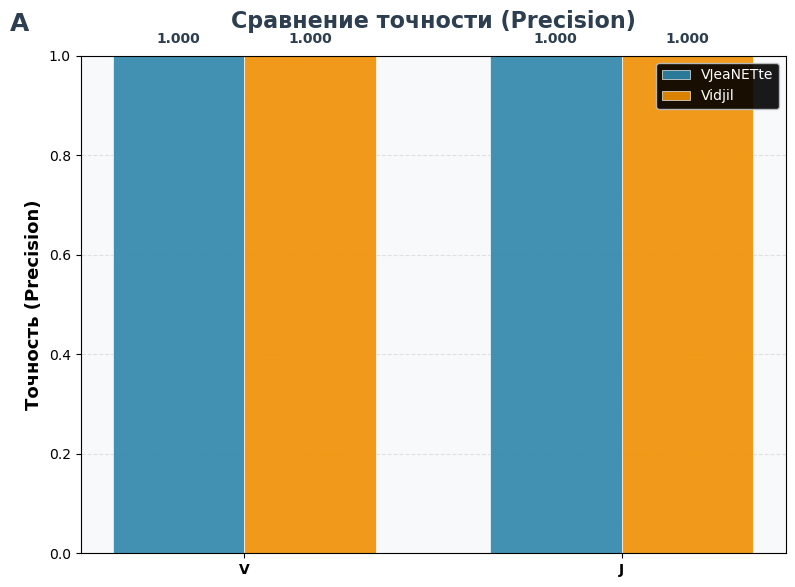

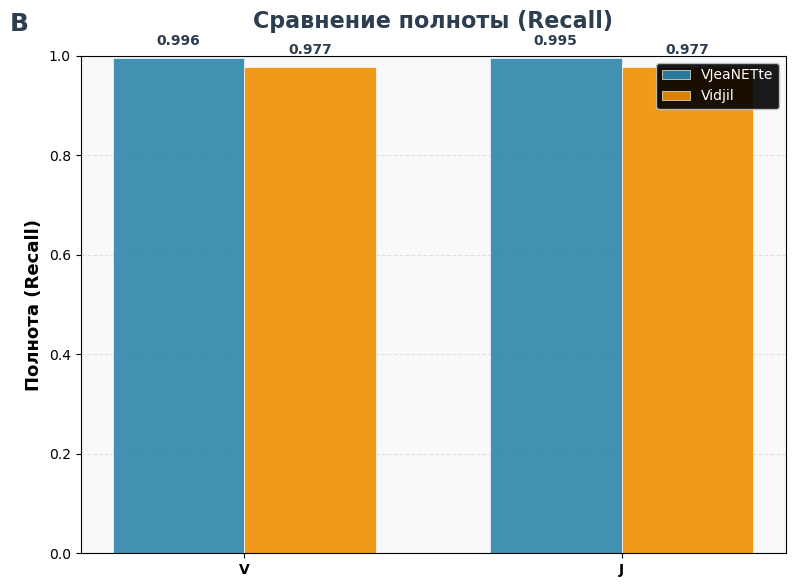

In [44]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

colors = ['#2E86AB', '#A23B72', '#F18F01']

# 1. Precision
fig1, ax1 = plt.subplots(figsize=(8, 6), facecolor='white')
ax1.set_facecolor('#f8f9fa')

labels = ["V", "J"]
x = np.arange(len(labels))
width = 0.35

precision_model = [precision_v_model, precision_j_model]
precision_vidjil = [precision_v_vidjil, precision_j_vidjil]

bars1_model = ax1.bar(x - width/2, precision_model, width, label='VJeaNETte', 
                      color=colors[0], alpha=0.9, edgecolor='white', linewidth=0.5)
bars1_vidjil = ax1.bar(x + width/2, precision_vidjil, width, label='Vidjil', 
                       color=colors[2], alpha=0.9, edgecolor='white', linewidth=0.5)

ax1.set_ylabel('Точность (Precision)', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.grid(True, alpha=0.2, linestyle='--')
ax1.set_axisbelow(True)

for bars in [bars1_model, bars1_vidjil]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, 
                fontweight='bold', color='#2c3e50')

ax1.set_title('Сравнение точности (Precision)', fontsize=16, fontweight='bold', 
              pad=20, color='#2c3e50')

legend1 = ax1.legend(loc='upper right', frameon=True, fancybox=True, 
                     framealpha=0.9, edgecolor='#bdc3c7')
legend1.get_frame().set_facecolor('black')

ax1.text(-0.1, 1.05, 'A', transform=ax1.transAxes, fontsize=18, 
         fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show()  

fig1.savefig('precision_plot.png', transparent=True, dpi=300, bbox_inches='tight')

# 2. Recall
fig2, ax2 = plt.subplots(figsize=(8, 6), facecolor='white')
ax2.set_facecolor('#f8f9fa')

recall_model = [recall_v_model, recall_j_model]
recall_vidjil = [recall_v_vidjil, recall_j_vidjil] 

bars2_model = ax2.bar(x - width/2, recall_model, width, label='VJeaNETte', 
                      color=colors[0], alpha=0.9, edgecolor='white', linewidth=0.5)
bars2_vidjil = ax2.bar(x + width/2, recall_vidjil, width, label='Vidjil', 
                       color=colors[2], alpha=0.9, edgecolor='white', linewidth=0.5)

ax2.set_ylabel('Полнота (Recall)', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontweight='bold')
ax2.set_ylim(0, 1.0)
ax2.grid(True, alpha=0.2, linestyle='--')
ax2.set_axisbelow(True)

for bars in [bars2_model, bars2_vidjil]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, 
                fontweight='bold', color='#2c3e50')

ax2.set_title('Сравнение полноты (Recall)', fontsize=16, fontweight='bold', 
              pad=20, color='#2c3e50')

legend2 = ax2.legend(loc='upper right', frameon=True, fancybox=True, 
                     framealpha=0.9, edgecolor='#bdc3c7')
legend2.get_frame().set_facecolor('black')

ax2.text(-0.1, 1.05, 'B', transform=ax2.transAxes, fontsize=18, 
         fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show() 

fig2.savefig('recall_plot.png', transparent=True, dpi=300, bbox_inches='tight')

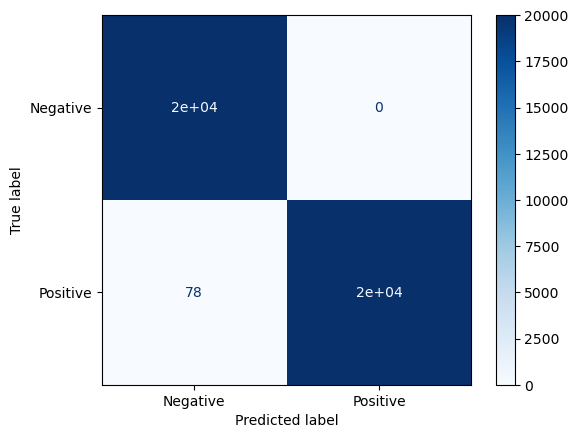

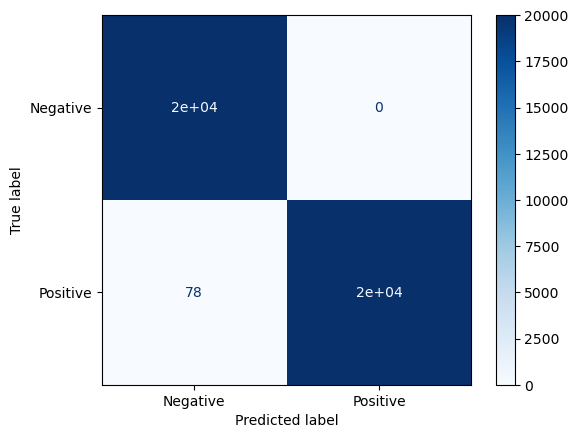

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Сбрасываем настройки стиля
plt.rcParams.update(plt.rcParamsDefault)

ConfusionMatrixDisplay.from_predictions(data_merged['has_v_x'], data_merged['has_v_y'], 
                                        display_labels=['Negative', 'Positive'],
                                        cmap='Blues')
plt.show()

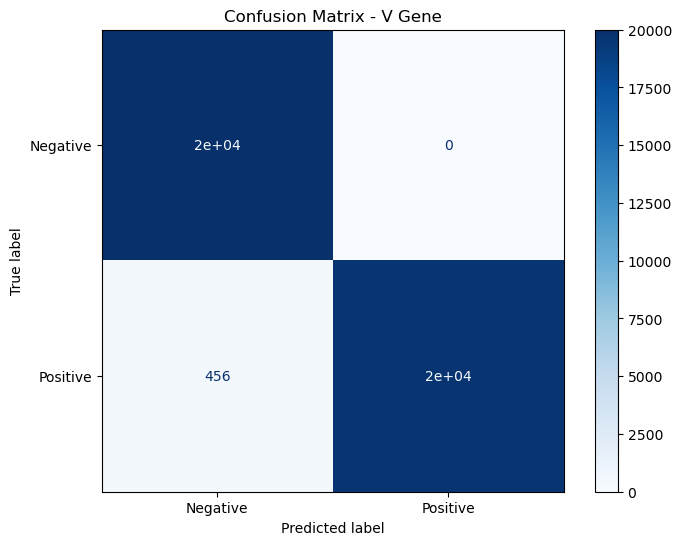

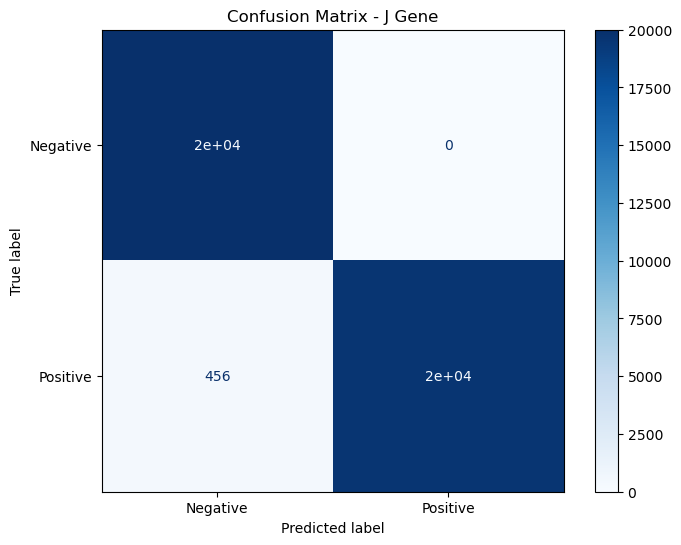

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Восстанавливаем метки
y_true_v = np.array([1]*TP_v_vidjil + [0]*FP_v_vidjil + [1]*FN_v_vidjil + [0]*TN_v_vidjil)
y_pred_v = np.array([1]*TP_v_vidjil + [1]*FP_v_vidjil + [0]*FN_v_vidjil + [0]*TN_v_vidjil)

y_true_j = np.array([1]*TP_j_vidjil + [0]*FP_j_vidjil + [1]*FN_j_vidjil + [0]*TN_j_vidjil)
y_pred_j = np.array([1]*TP_j_vidjil + [1]*FP_j_vidjil + [0]*FN_j_vidjil + [0]*TN_j_vidjil)

# Строим confusion matrix для V-генов
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_true_v, y_pred_v, 
                                        display_labels=['Negative', 'Positive'],
                                        cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix - V Gene')
plt.show()

# Строим confusion matrix для J-генов
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_true_j, y_pred_j, 
                                        display_labels=['Negative', 'Positive'],
                                        cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix - J Gene')
plt.show()